In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("Amazon.csv")
df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

**1.What are the top 10 most expensive products?**

In [5]:
top_expensive = df.nlargest(10, 'TotalAmount')
top_expensive


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
48442,ORD0048443,2020-01-12,CUST010794,Anjali Patel,P00033,Puzzle 1000pc,Home & Kitchen,UrbanStyle,5,598.29,0.0,538.46,5.07,3534.98,Amazon Pay,Shipped,San Diego,CA,India,SELL00471
81886,ORD0081887,2020-09-26,CUST031626,Vivaan Joshi,P00048,Wireless Charger,Toys & Games,HomeEase,5,596.47,0.0,536.82,2.68,3521.85,UPI,Shipped,Denver,CO,United States,SELL00354
4196,ORD0004197,2021-02-22,CUST022868,Kabir Gupta,P00029,T-Shirt,Home & Kitchen,Zenith,5,595.26,0.0,535.73,2.21,3514.24,Credit Card,Delivered,San Francisco,CA,United States,SELL00601
1929,ORD0001930,2023-08-18,CUST031209,Pooja Patel,P00025,Running Shoes,Books,KiddoFun,5,594.85,0.0,535.36,4.04,3513.65,UPI,Delivered,Phoenix,AZ,United Kingdom,SELL00955
58204,ORD0058205,2021-10-19,CUST033287,Priya Gupta,P00031,Kids Toy Car,Home & Kitchen,FitLife,5,594.46,0.0,535.01,5.74,3513.05,UPI,Delivered,San Antonio,TX,United States,SELL01072
46764,ORD0046765,2024-04-13,CUST044400,Priya Kapoor,P00034,Desk Organizer,Home & Kitchen,FitLife,5,594.82,0.0,535.34,2.51,3511.95,Net Banking,Shipped,Los Angeles,CA,United States,SELL01587
40146,ORD0040147,2024-10-07,CUST001991,Pooja Mehta,P00002,Bluetooth Speaker,Books,NexPro,5,593.30,0.0,533.97,9.76,3510.23,Cash on Delivery,Delivered,Los Angeles,CA,United States,SELL01921
20578,ORD0020579,2023-09-24,CUST016754,Sneha Sharma,P00015,Instant Pot,Sports & Outdoors,Apex,5,593.94,0.0,534.55,5.05,3509.30,Amazon Pay,Delivered,San Diego,CA,United States,SELL00531
95429,ORD0095430,2023-03-08,CUST001586,Sunita Joshi,P00006,Gaming Mouse,Books,Apex,5,591.55,0.0,532.40,9.00,3499.15,Net Banking,Shipped,Jacksonville,FL,Australia,SELL00956
51547,ORD0051548,2024-03-22,CUST024376,Vihaan Gupta,P00013,Action Camera,Home & Kitchen,Zenith,5,591.09,0.0,531.98,10.70,3498.13,Net Banking,Delivered,San Jose,CA,India,SELL00222


**2.Which product category has the highest average price?**

In [6]:
category_avg_price = df.groupby('Category')['TotalAmount'].mean().sort_values(ascending=False)
category_avg_price.head(1)


Category
Clothing    927.878673
Name: TotalAmount, dtype: float64

**3.Identify categories with the most products**

In [7]:
category_counts = df['Category'].value_counts()
category_counts



Category
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439
Name: count, dtype: int64

**4.Visualize using a bar chart.**

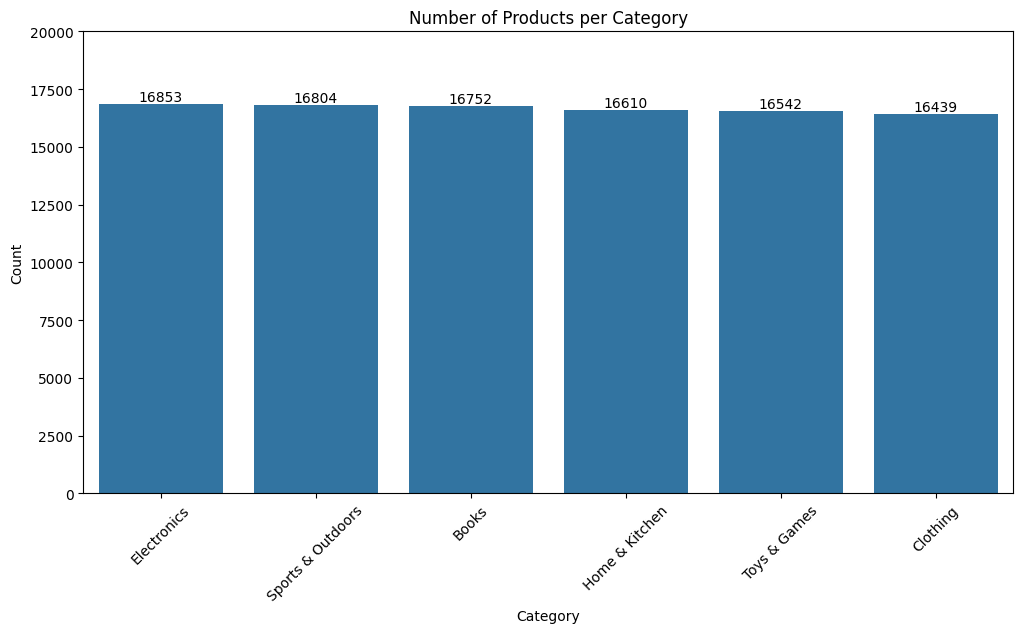

In [14]:
plt.figure(figsize=(12,6))

ax = sns.barplot(x=category_counts.index, y=category_counts.values)

plt.title("Number of Products per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.ylim(0, 20000)
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),       
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, color='black'
    )
plt.show()



**5.Calculate the average discount percentage per category.**

In [15]:
avg_discount = df.groupby('Category')['Discount'].mean().sort_values(ascending=False)
avg_discount


Category
Home & Kitchen       0.075084
Electronics          0.074340
Toys & Games         0.074066
Sports & Outdoors    0.074000
Clothing             0.073970
Books                0.073896
Name: Discount, dtype: float64

**6.Find the correlation between price, quantity, discount, etc**

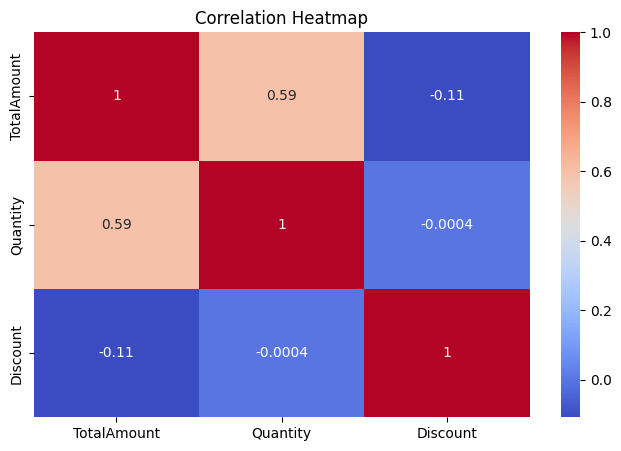

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['TotalAmount','Quantity','Discount']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**7.What is the distribution of product prices?
Plot a histogram or KDE plot.**

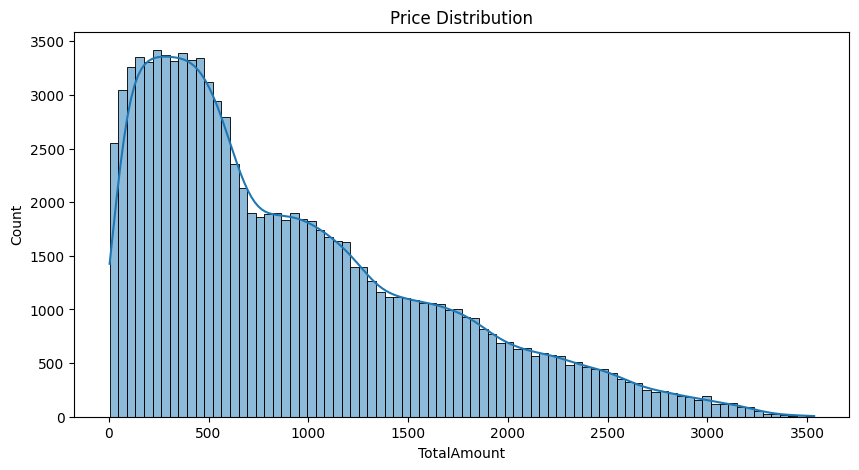

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df['TotalAmount'], kde=True)
plt.title("Price Distribution")
plt.show()


**8.Identify outliers in the price column using:IQR method**


In [20]:
Q1 = df['TotalAmount'].quantile(0.25)
Q3 = df['TotalAmount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['TotalAmount'] < lower) | (df['TotalAmount'] > upper)]
outliers.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
18,ORD0000019,2024-08-14,CUST040211,Aditya Mehta,P00033,Puzzle 1000pc,Electronics,ReadMore,5,529.19,0.00,317.51,4.57,2968.03,Amazon Pay,Returned,Phoenix,AZ,United States,SELL01907
72,ORD0000073,2023-09-25,CUST043454,Priya Reddy,P00027,Winter Jacket,Toys & Games,CoreTech,5,582.66,0.00,233.06,14.07,3160.43,UPI,Shipped,Dallas,TX,United States,SELL00749
235,ORD0000236,2020-11-13,CUST025402,Priya Mehta,P00030,Dress Shirt,Electronics,Apex,5,574.24,0.00,143.56,13.09,3027.85,Credit Card,Shipped,Chicago,IL,United States,SELL00618
263,ORD0000264,2021-10-03,CUST002544,Arjun Sharma,P00050,Novel Bestseller,Home & Kitchen,Zenith,5,567.72,0.05,323.60,10.53,3030.80,Credit Card,Delivered,Fort Worth,TX,United States,SELL00789
265,ORD0000266,2024-05-08,CUST049849,Sneha Singh,P00036,Smart Light Bulb,Electronics,BrightLux,5,594.86,0.00,237.94,2.37,3214.61,Debit Card,Delivered,Seattle,WA,United States,SELL00669


**8.1 Boxplot visualization**

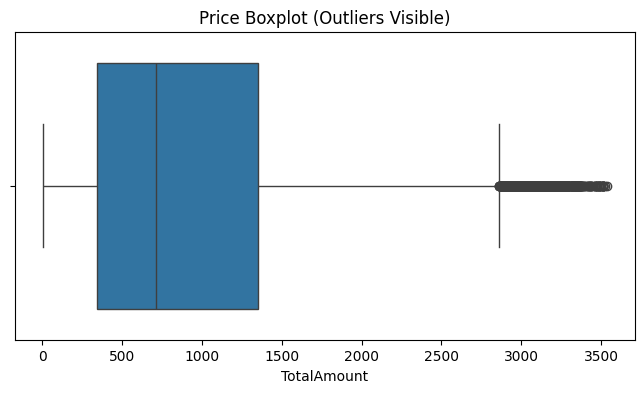

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['TotalAmount'])
plt.title("Price Boxplot (Outliers Visible)")
plt.show()


**9.Find the top 10 best deals by:Highest discount %**


In [23]:
best_discount = df.nlargest(10, 'Discount')
best_discount

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
52,ORD0000053,2024-05-09,CUST012995,Ritika Mehta,P00050,Novel Bestseller,Electronics,NexPro,3,324.76,0.3,34.10,0.75,716.85,Debit Card,Shipped,Seattle,WA,United States,SELL00962
58,ORD0000059,2021-10-08,CUST031615,Arjun Singh,P00016,Air Fryer,Toys & Games,Apex,3,184.70,0.3,46.54,7.98,442.39,Debit Card,Delivered,Dallas,TX,United States,SELL00280
150,ORD0000151,2022-12-07,CUST038774,Kabir Sharma,P00015,Instant Pot,Clothing,ReadMore,4,306.01,0.3,42.84,9.24,908.91,Debit Card,Delivered,Austin,TX,United Kingdom,SELL00672
179,ORD0000180,2024-09-10,CUST044928,Pooja Reddy,P00001,Wireless Earbuds,Sports & Outdoors,CoreTech,1,418.70,0.3,23.45,4.48,321.02,UPI,Delivered,Jacksonville,FL,United States,SELL00811
229,ORD0000230,2023-07-06,CUST031415,Aman Reddy,P00033,Puzzle 1000pc,Toys & Games,UrbanStyle,5,493.81,0.3,138.27,14.70,1881.30,Amazon Pay,Pending,Denver,CO,United States,SELL00905
251,ORD0000252,2023-07-15,CUST019542,Priya Reddy,P00014,Drone Mini,Clothing,Apex,5,274.55,0.3,48.05,5.27,1014.24,Debit Card,Pending,Washington,DC,United States,SELL00946
378,ORD0000379,2020-06-09,CUST044236,Sahil Reddy,P00013,Action Camera,Toys & Games,Zenith,3,47.17,0.3,7.92,0.96,107.94,Debit Card,Delivered,San Francisco,CA,United Kingdom,SELL01385
390,ORD0000391,2022-11-22,CUST037892,Kabir Gupta,P00039,Graphic Tablet,Books,Apex,3,412.81,0.3,69.35,6.62,942.87,Debit Card,Delivered,Denver,CO,United States,SELL00120
401,ORD0000402,2023-10-20,CUST016596,Priya Joshi,P00017,Electric Kettle,Home & Kitchen,HomeEase,2,466.29,0.3,52.22,7.92,712.95,Debit Card,Shipped,San Antonio,TX,United Kingdom,SELL01723
418,ORD0000419,2021-10-20,CUST037096,Ritika Mehta,P00013,Action Camera,Home & Kitchen,Zenith,3,495.51,0.3,124.87,4.78,1170.22,Net Banking,Pending,San Diego,CA,United States,SELL01193


**10.Create a category-wise price comparison boxplot**

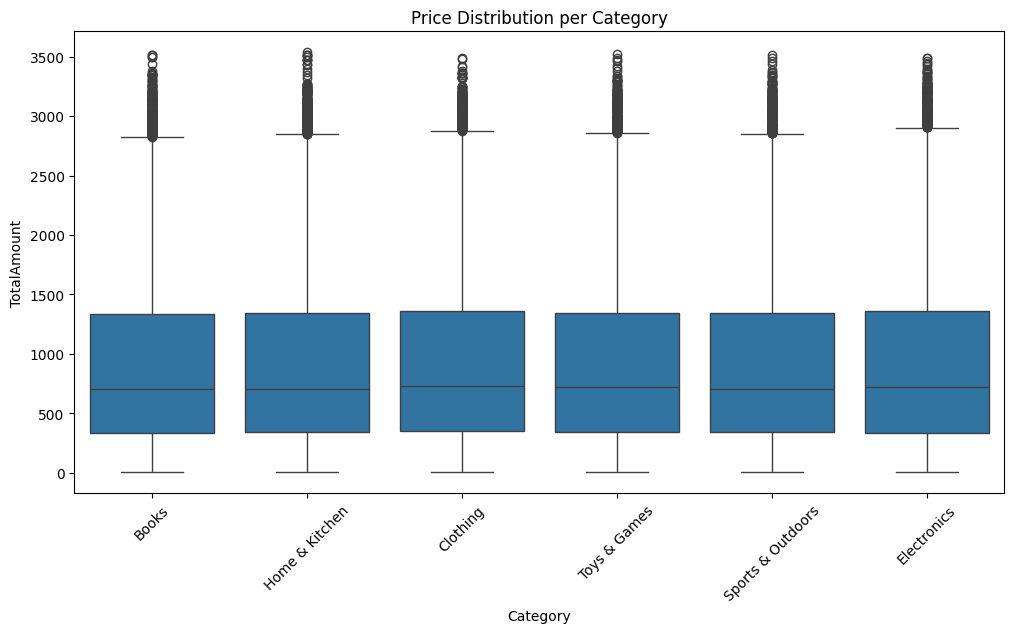

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='TotalAmount', data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution per Category")
plt.show()


In [1]:
X = df[['TotalAmount','Discount']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


NameError: name 'df' is not defined

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,cluster
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,1
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,1
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,0
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,0


In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['price'], y=df['rating'], 
    hue=df['cluster'], palette='deep'
)
plt.title("Product Clusters (Price vs Rating)")
plt.show()
